In [ ]:
.

        23MID0019
        JEEVANTH S 

.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
import scipy.cluster.hierarchy as sch
from sklearn.decomposition import PCA

# Setting visual style
sns.set(style="whitegrid")

In [2]:
# Load the dataset
df = pd.read_csv('TitanicDataset.csv')

X = df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin', 'Survived'])

# 2. Handle missing values
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Fare'] = X['Fare'].fillna(X['Fare'].median())

# 3. Encode Categorical Variables (Sex and Embarked)
le = LabelEncoder()
X['Sex'] = le.fit_transform(X['Sex'])
X['Embarked'] = le.fit_transform(X['Embarked'].astype(str))

# 4. Feature Scaling (Crucial for distance-based algorithms like KMeans)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Preprocessing complete. Scaled data shape:", X_scaled.shape)

Preprocessing complete. Scaled data shape: (418, 7)


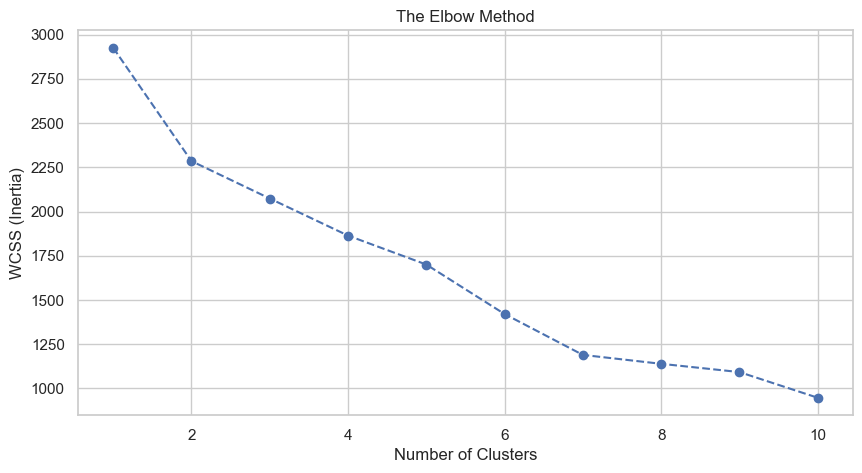

In [3]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Inertia)')
plt.show()

In [12]:
# Applying KMeans to the dataset
kmeans = KMeans(n_clusters=3, init='k-means++', random_state=42)
df['KMeans_Cluster'] = kmeans.fit_predict(X_scaled)

print("K-Means clustering complete.")
print(df['KMeans_Cluster'].value_counts())

K-Means clustering complete.
KMeans_Cluster
1    280
2    109
0     29
Name: count, dtype: int64


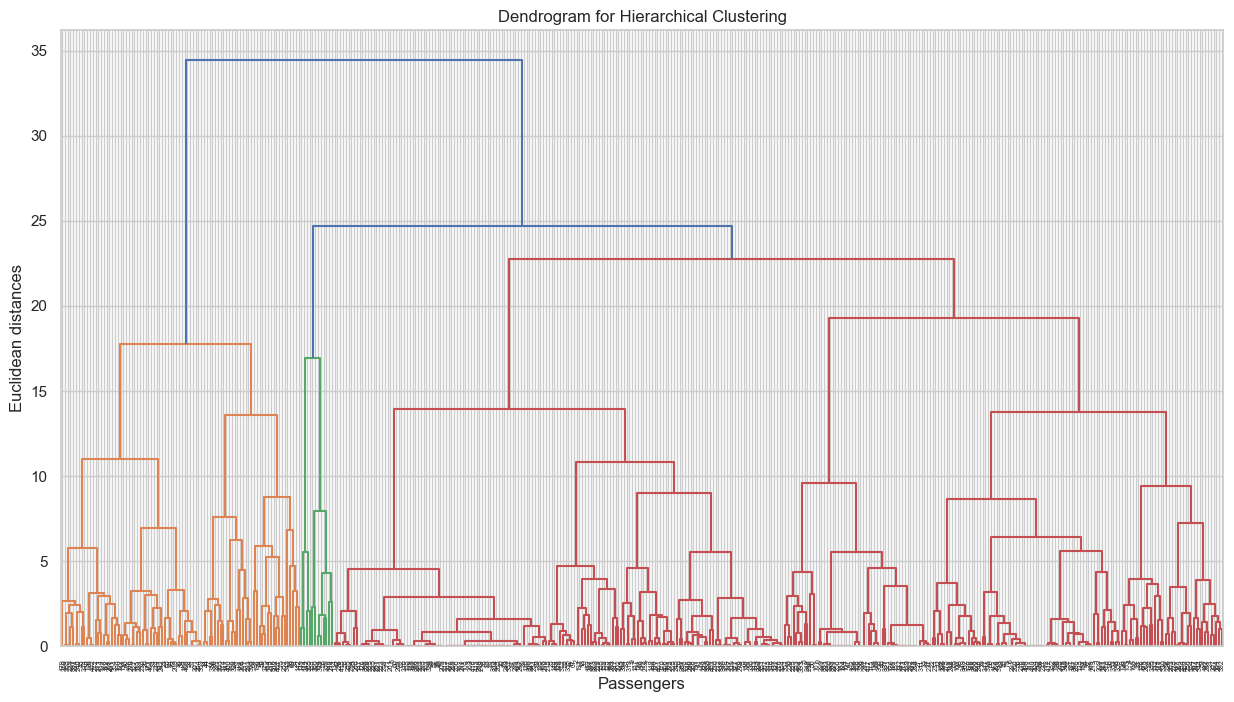

In [13]:
plt.figure(figsize=(15, 8))
dendrogram = sch.dendrogram(sch.linkage(X_scaled, method='ward'))
plt.title('Dendrogram for Hierarchical Clustering')
plt.xlabel('Passengers')
plt.ylabel('Euclidean distances')
plt.show()

In [14]:
# 'affinity' was renamed to 'metric' in scikit-learn 1.2+
hc = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='ward')
df['Hierarchical_Cluster'] = hc.fit_predict(X_scaled)

print("Hierarchical clustering complete. Cluster counts:")
print(df['Hierarchical_Cluster'].value_counts())

Hierarchical clustering complete. Cluster counts:
Hierarchical_Cluster
0    320
1     86
2     12
Name: count, dtype: int64


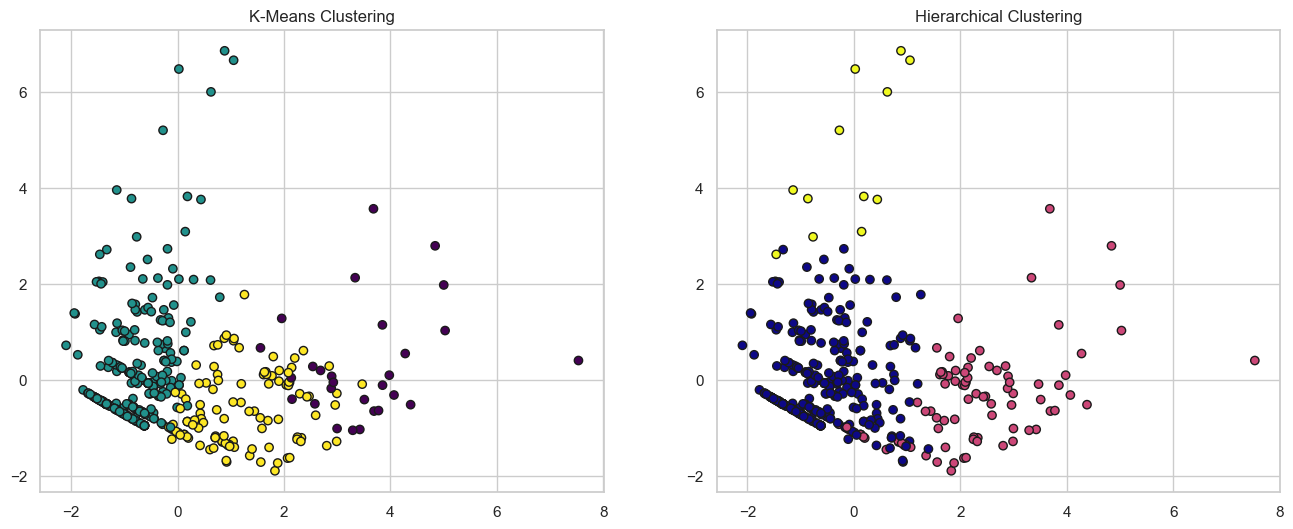

In [15]:
# Ensure we have the clusters before plotting
if 'KMeans_Cluster' not in df.columns or 'Hierarchical_Cluster' not in df.columns:
    print("ERROR: Please run Cell 4 and Cell 6 before this cell!")
else:
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X_scaled)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Plot KMeans
    ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=df['KMeans_Cluster'], cmap='viridis', edgecolors='k')
    ax1.set_title('K-Means Clustering')

    # Plot Hierarchical
    ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=df['Hierarchical_Cluster'], cmap='plasma', edgecolors='k')
    ax2.set_title('Hierarchical Clustering')

    plt.show()